In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Starting ML Pipeline
File loaded successfully

Shape: (10000, 10)

Columns: ['Employee_ID', 'Name', 'Age', 'Gender', 'Department', 'Job_Title', 'Experience_Years', 'Education_Level', 'Location', 'Salary']

Missing Values:
 Employee_ID         0
Name                0
Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

 Duplicate Values:
 0

Summary:
        Employee_ID           Age  Experience_Years         Salary
count  10000.00000  10000.000000      10000.000000   10000.000000
mean    5000.50000     35.455900         12.370900  115381.500000
std     2886.89568     10.000213          9.148951   46066.139047
min        1.00000     21.000000          0.000000   25000.000000
25%     2500.75000     27.000000          5.000000   70000.000000
50%     5000.50000     34.000000         10.000000  120000.000000
75%     7500.25000     43.000000         19.0000

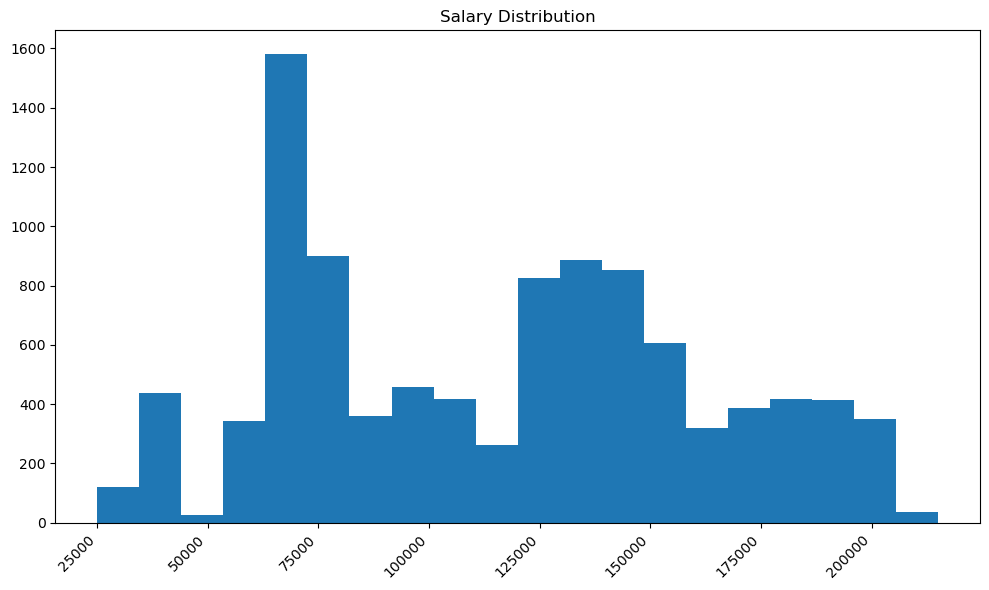

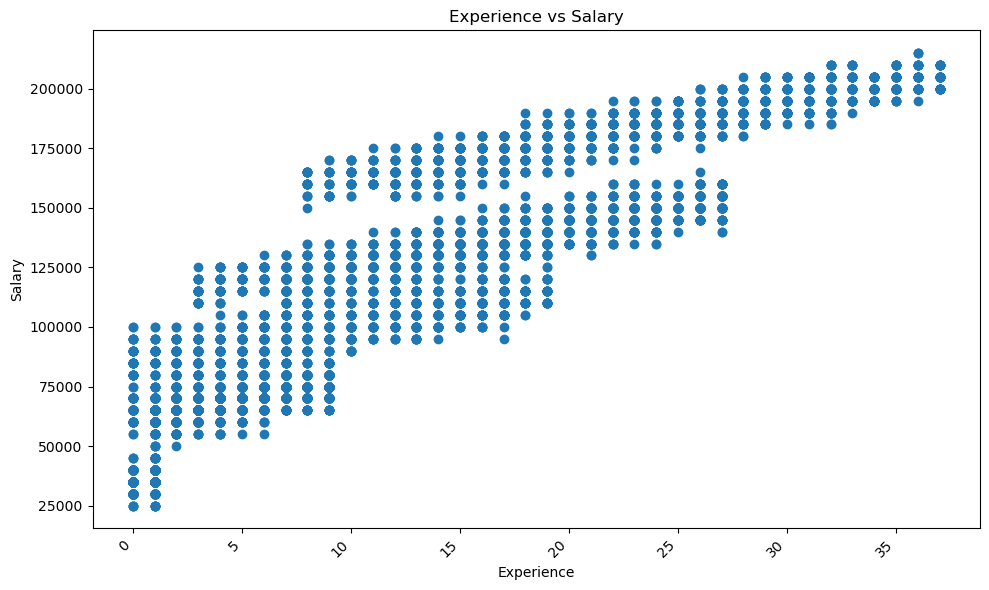

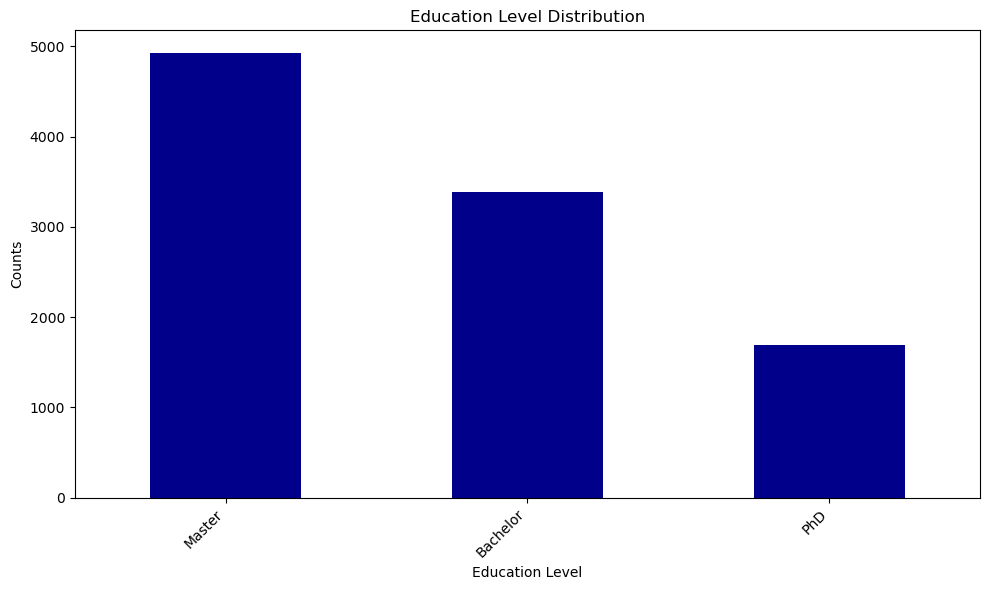

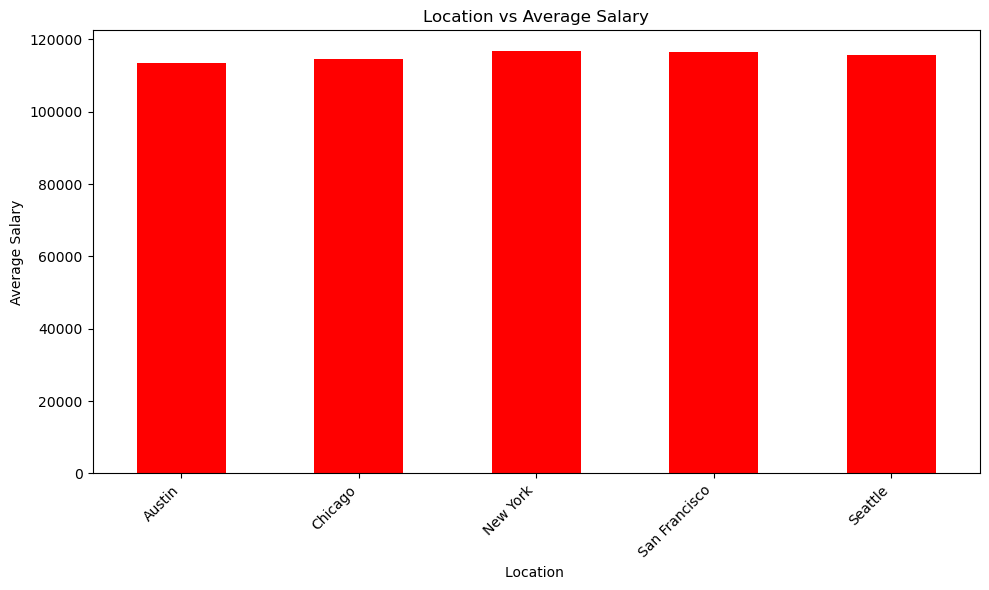

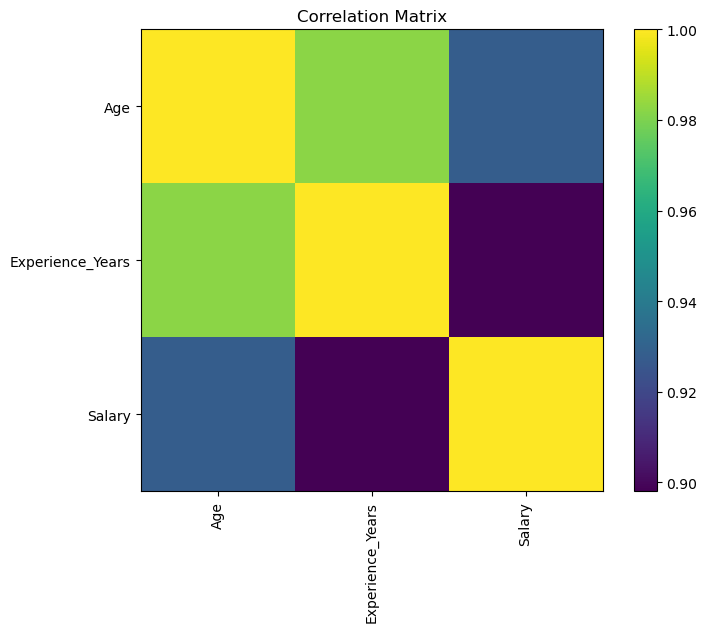


Model Performance
R2 Score: 0.9917562580370476
Mean Squared Error: 17375021.62159681
Mean Absolute Error: 3337.9377580363407
Root Mean Squared Error: 4168.335593686863


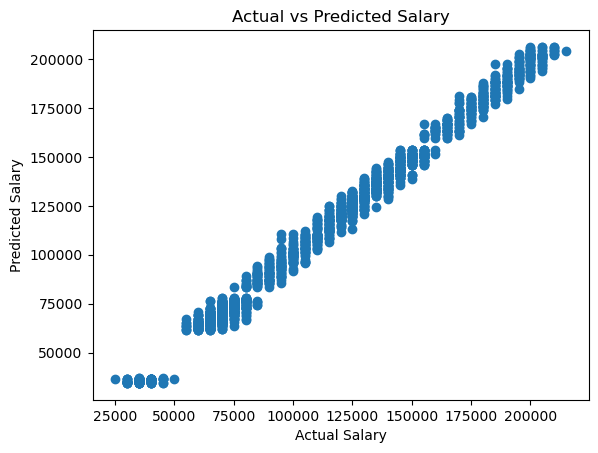


Pipeline Completed Successfully!


In [3]:
FILE_PATH = 'Employers_data.csv'
TARGET = 'Salary'

# Data
def load_data(path):
    df = pd.read_csv(path)
    print("File loaded successfully")
    return df

# Overview of Data
def data_overview(df):
    print("\nShape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())
    print("\n Duplicate Values:\n" , df.duplicated().sum())
    print("\nSummary:\n", df.describe())


# EDA
def perform_eda(df):

    # Histogram for Salary
    plt.figure(figsize = (10, 6))
    plt.hist(df['Salary'], bins=20)
    plt.title("Salary Distribution")
    plt.xticks(rotation = 45 , ha = "right")
    plt.tight_layout()
    plt.show()

    # Scatter plot for Experience years and salary
    plt.figure(figsize = (10, 6))
    plt.scatter(df['Experience_Years'], df['Salary'])
    plt.title("Experience vs Salary")
    plt.xlabel("Experience")
    plt.ylabel("Salary")
    plt.xticks(rotation = 45 , ha = "right")
    plt.tight_layout()
    plt.show()

    # Education levels Distribution
    plt.figure(figsize = (10, 6))
    df['Education_Level'].value_counts().plot(kind='bar', color = "darkblue")
    plt.title("Education Level Distribution")
    plt.xlabel("Education Level")
    plt.ylabel("Counts")
    plt.xticks(rotation = 45 , ha = "right")
    plt.tight_layout()
    plt.show()

    # Average Salary by Location
    plt.figure(figsize = (10, 6))
    df.groupby('Location')['Salary'].mean().plot(kind='bar' , color = "red")
    plt.title("Location vs Average Salary")
    plt.xlabel("Location ")
    plt.ylabel("Average Salary")
    plt.xticks(rotation = 45 , ha = "right")
    plt.tight_layout()
    plt.show()

    # Correlation Heatmap
    df_temp = df.drop(['Employee_ID'], axis=1, errors='ignore')
    corr = df_temp.corr(numeric_only=True)

    plt.figure(figsize=(8,6))
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.show()


# Preprocessed data
def preprocess_data(df):

    # Drop useless columns for model
    df = df.drop(['Employee_ID', 'Name'], axis=1, errors='ignore')

    # Encoding the categorical columns
    cat_cols = df.select_dtypes(include='object').columns
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    return df

# Train Model
def train_model(df):

    df = preprocess_data(df)

    X = df.drop(TARGET, axis=1)
    y = df[TARGET]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size= 0.2,random_state= 42)

    model = LinearRegression()
    model.fit(x_train, y_train)

    return model, x_test, y_test


# Evaluate Model
def evaluate_model(model, x_test, y_test):

    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print("\nModel Performance")
    print("R2 Score:", r2)
    print("Mean Squared Error:", mse)
    print("Mean Absolute Error:", mae)
    print("Root Mean Squared Error:", rmse)

    # Plot
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.title("Actual vs Predicted Salary")
    plt.xlabel("Actual Salary")
    plt.ylabel("Predicted Salary")
    plt.show()


# Main Pipeline
def main():

    print("Starting ML Pipeline")

    df = load_data(FILE_PATH)

    data_overview(df)

    perform_eda(df)

    model, x_test, y_test = train_model(df)

    evaluate_model(model, x_test, y_test)

    print("\nPipeline Completed Successfully!")


if __name__ == "__main__":
    main()